In [1]:
%run ../scripts/notebook_settings_lean.py
from scipy import stats
pd.options.display.float_format = '{:10,.3g}'.format 

Quick proportion checks based on the raw rfmix output files.

In [4]:
def create_paint_df_ind_compressed(df, ind, mapping, ns_map):
    d = {}
    max_pos = int(df.epos.iloc[-1])
    df = df.loc[df[ind].shift() != df[ind]].reset_index()
    df["epos"] = pd.concat([df.spos.iloc[1:], pd.Series(max_pos)], ignore_index=True)
    d["pos"] = df.spos
    d["end_pos"] = df.epos -1
    d["length"] = df.epos - df.spos
    d["reference"] = df[ind].map(mapping)
    d["n/s"] = d["reference"].map(ns_map)
    d["individual"] = ind[:-2]
    d["haplotype"] = ind[-1:]
    return pd.DataFrame(d)

def create_paint_df_ind(df, ind, mapping, ns_map):
    d = {}
    d["pos"] = df.spos
    d["end_pos"] = df.epos -1
    d["length"] = df.epos - df.spos
    d["reference"] = df[ind].map(mapping)
    d["n/s"] = d["reference"].map(ns_map)
    d["individual"] = ind[:-2]
    d["haplotype"] = ind[-1:]
    return pd.DataFrame(d)

In [2]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/tanzania_pure_focus/"
mapping_df = pd.read_csv("../steps/rfmix_gen100/tanzania_close_focus/" + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
north_south_mapping = {'Gog Woreda, Gambella region, Ethiopia': 1,
                         'Mikumi, Tanzania': -1,
                          'Mahale, Tanzania': -1}

In [8]:
df_l = []
for chrom in ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)
length_df["chrom_type"] = ["all_chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in length_df.chrom]

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX
female_ref_chrX


In [15]:
ruaha_ids = meta_data_samples.loc[meta_data_samples.Origin == "Ruaha, Tanzania"].PGDP_ID
ruaha_df = length_df.loc[length_df.individual.isin(ruaha_ids)].copy()

([0, 1, 2, 3],
 [Text(0, 0, 'all_chrX'),
  Text(1, 0, 'autosome'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

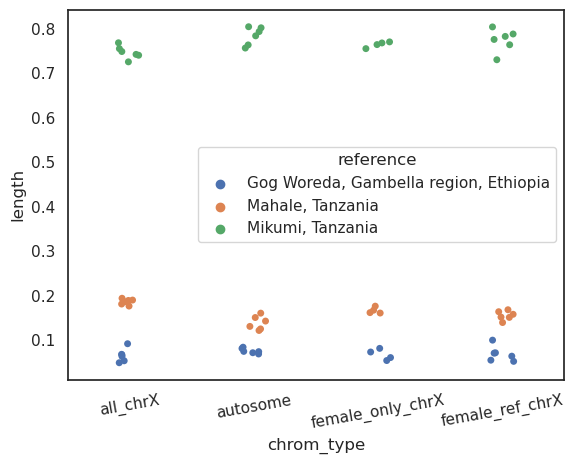

In [19]:
percent_df = (ruaha_df.groupby(["chrom_type", "individual", "reference"])[["length"]].sum()/ruaha_df.groupby(["chrom_type", "individual"])[["length"]].sum()).reset_index()
sns.stripplot(percent_df, x="chrom_type", y="length", hue="reference")
plt.xticks(rotation=10)

([0, 1, 2, 3],
 [Text(0, 0, 'all_chrX'),
  Text(1, 0, 'autosome'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

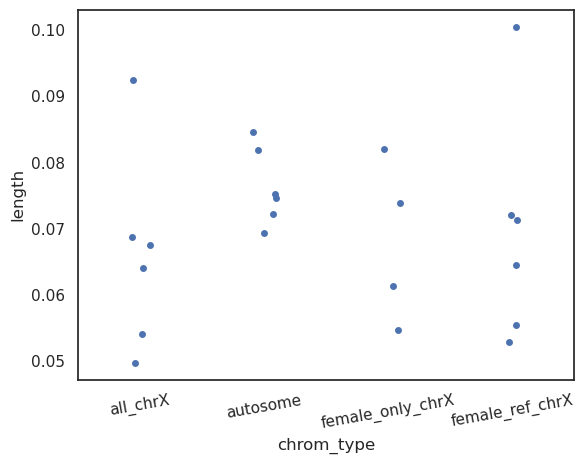

In [25]:
percent_df = (ruaha_df.groupby(["chrom_type", "individual", "reference"])[["length"]].sum()/ruaha_df.groupby(["chrom_type", "individual"])[["length"]].sum()).reset_index()
percent_df = percent_df.loc[percent_df.reference == "Gog Woreda, Gambella region, Ethiopia"]
sns.stripplot(percent_df, x="chrom_type", y="length")
plt.xticks(rotation=10)

In [32]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/tanzania_pure_focus_plain/"
mapping_df = pd.read_csv("../steps/rfmix_gen100/tanzania_close_focus/" + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
north_south_mapping = {'Gog Woreda, Gambella region, Ethiopia': 1,
                         'Mikumi, Tanzania': -1,
                          'Mahale, Tanzania': -1}

In [33]:
df_l = []
for chrom in ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)
length_df["chrom_type"] = ["all_chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in length_df.chrom]

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX
female_ref_chrX


([0, 1, 2, 3],
 [Text(0, 0, 'all_chrX'),
  Text(1, 0, 'autosome'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

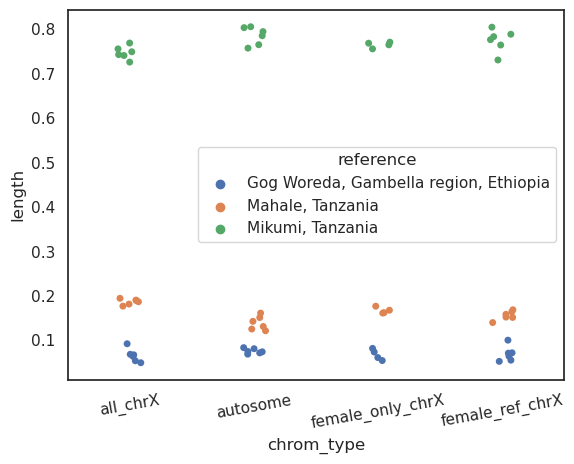

In [34]:
ruaha_ids = meta_data_samples.loc[meta_data_samples.Origin == "Ruaha, Tanzania"].PGDP_ID
ruaha_df = length_df.loc[length_df.individual.isin(ruaha_ids)].copy()
percent_df = (ruaha_df.groupby(["chrom_type", "individual", "reference"])[["length"]].sum()/ruaha_df.groupby(["chrom_type", "individual"])[["length"]].sum()).reset_index()
sns.stripplot(percent_df, x="chrom_type", y="length", hue="reference")
plt.xticks(rotation=10)

([0, 1, 2, 3],
 [Text(0, 0, 'all_chrX'),
  Text(1, 0, 'autosome'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

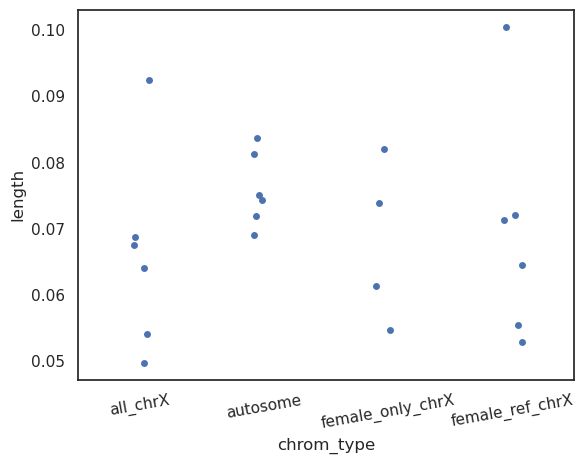

In [35]:
percent_df = (ruaha_df.groupby(["chrom_type", "individual", "reference"])[["length"]].sum()/ruaha_df.groupby(["chrom_type", "individual"])[["length"]].sum()).reset_index()
percent_df = percent_df.loc[percent_df.reference == "Gog Woreda, Gambella region, Ethiopia"]
sns.stripplot(percent_df, x="chrom_type", y="length")
plt.xticks(rotation=10)

In [26]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/tanzania_close_focus/"
mapping_df = pd.read_csv("../steps/rfmix_gen100/tanzania_close_focus/" + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
north_south_mapping = {'Gog Woreda, Gambella region, Ethiopia': 1,
                         'Mikumi, Tanzania': -1,
                          'Mahale, Tanzania': -1}

In [27]:
df_l = []
for chrom in ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)
length_df["chrom_type"] = ["all_chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in length_df.chrom]

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX
female_ref_chrX


([0, 1, 2, 3],
 [Text(0, 0, 'all_chrX'),
  Text(1, 0, 'autosome'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

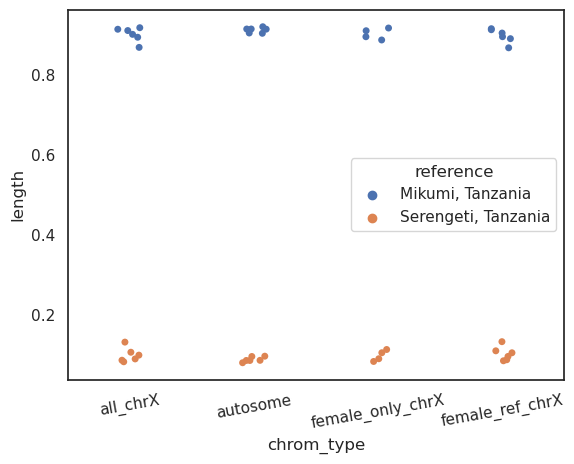

In [28]:
ruaha_ids = meta_data_samples.loc[meta_data_samples.Origin == "Ruaha, Tanzania"].PGDP_ID
ruaha_df = length_df.loc[length_df.individual.isin(ruaha_ids)].copy()
percent_df = (ruaha_df.groupby(["chrom_type", "individual", "reference"])[["length"]].sum()/ruaha_df.groupby(["chrom_type", "individual"])[["length"]].sum()).reset_index()
sns.stripplot(percent_df, x="chrom_type", y="length", hue="reference")
plt.xticks(rotation=10)

([0, 1, 2, 3],
 [Text(0, 0, 'all_chrX'),
  Text(1, 0, 'autosome'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

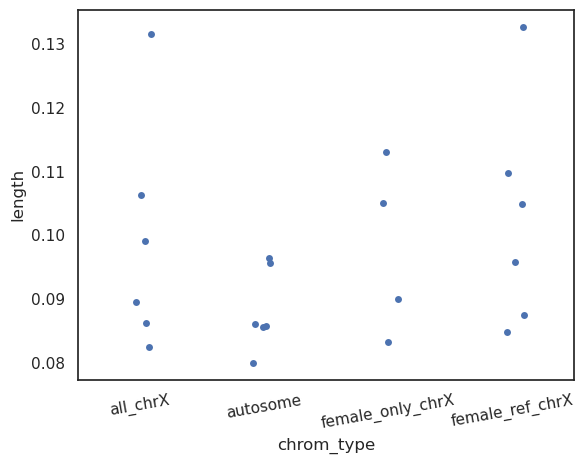

In [31]:
percent_df = (ruaha_df.groupby(["chrom_type", "individual", "reference"])[["length"]].sum()/ruaha_df.groupby(["chrom_type", "individual"])[["length"]].sum()).reset_index()
percent_df = percent_df.loc[percent_df.reference == "Serengeti, Tanzania"]
sns.stripplot(percent_df, x="chrom_type", y="length")
plt.xticks(rotation=10)

Determining which reference setup to use for the main article based on simulations. ChrX admixture case between Gog/Mikumi sim on chromosome X (with two admixture dates, one 50 generations ago and one 250 generations ago).